# nb11 -- MLP variant comparison
Trains all 12 (architecture, penalty) variants from `src/models/architectures.py`
on the same corrected RNA -> protein data, and compares them on accuracy
(train/test Pearson r) and interpretability (cognate rank-1 count, effective
genes per protein).

Consolidates what nb05-nb09 did across five separate notebooks into one run.
nb05-nb09 are left as-is for history; this notebook is the current pipeline
going forward, and the one to re-point at NeurIPS (GSE194122) later.

All model/training/evaluation logic lives in `src/models/architectures.py`,
`src/training/train.py`, `src/analysis/evaluate.py` -- this notebook is
execution only, no function definitions beyond the data-normalization block
(not yet extracted to `src/`, see note below).

## Environment setup (Colab or local)

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata scikit-misc
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


## GPU check

In [2]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device (training only):', DEVICE)

Device (training only): cuda


## Imports and config
`src/models`, `src/training`, `src/analysis` are real packages under `BASE_PATH`
(no `__init__.py` needed -- Python 3 namespace packages), so they import
directly once `BASE_PATH` is on `sys.path`.

In [ ]:
import sys
sys.path.insert(0, str(BASE_PATH))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from src.models.architectures import VARIANTS, build_variant
from src.training.train import fit_model, make_loader
from src.analysis.normalize import normalize_rna, clr_normalize, regress_out_library_size
from src.analysis.evaluate import (
    evaluate_per_protein,
    compute_importance,
    cognate_gene_rank,
    effective_genes_per_protein,
    train_test_metrics,
)

CHECKPOINT_PATH    = BASE_PATH / 'data' / 'processed' / 'covid_subsampled.h5ad'
GENE_MAPPING_PATH  = BASE_PATH / 'results' / 'tables' / 'nb02_covid_adt_gene_mapping.csv'
RESULTS_DIR        = BASE_PATH / 'results' / 'mlp_variant_comparison'
MODELS_DIR         = RESULTS_DIR / 'checkpoints'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

N_HVGS       = 2000
DROP_GENES   = ['PDPN', 'KDR']  # zero-variance in GEX (see nb02 Step 3b)

HIDDEN_DIM   = 64      # defined here, not hardcoded in src/models/architectures.py
BATCH_SIZE   = 256
NUM_EPOCHS   = 100
PATIENCE     = 15

TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
RANDOM_STATE  = 42

# Train all 12 registered variants by default -- narrow this list to re-run a subset.
VARIANTS_TO_RUN = list(VARIANTS.keys())
print('Variants to run:', VARIANTS_TO_RUN)

Variants to run: ['mlp_no_l1', 'mlp_fc1', 'mlp_fc2', 'mlp_fc1_fc2', 'mlp_fc1_group_fc2', 'lasso', 'skip_no_l1', 'skip_fc1', 'skip_fc2', 'skip_fc1_fc2', 'skip_fc1_fc2_direct', 'skip_direct']


## Load checkpoint and gene mapping
Same as nb05-nb09 -- splits GEX/ADT, rebuilds the 163-gene matched set from the saved mapping.

In [4]:
covid = sc.read_h5ad(CHECKPOINT_PATH)

gex_mask = covid.var['feature_types'] == 'Gene Expression'
adt_mask = covid.var['feature_types'] == 'Antibody Capture'
covid_gex = covid[:, gex_mask].copy()
covid_adt = covid[:, adt_mask].copy()

gene_map = pd.read_csv(GENE_MAPPING_PATH)
gene_map = gene_map[~gene_map['gene'].isin(DROP_GENES)]
matched_genes     = gene_map['gene'].tolist()
matched_adt_names = gene_map['adt_name'].tolist()

print(f'GEX: {covid_gex.shape}, ADT: {covid_adt.shape}')
print(f'Matched genes/proteins: {len(matched_genes)}')

KeyboardInterrupt: 

## Gene union (matched + HVG)
Same construction as nb03/nb05-nb09 -- matched coupling genes are always kept
even if not top-variance. Not yet extracted to `src/` -- candidate for a future
`src/preprocessing.py` alongside the normalization block below.

In [ ]:
covid_gex.layers['counts'] = covid_gex.layers['raw'].copy()

sc.pp.highly_variable_genes(
    covid_gex, n_top_genes=N_HVGS, flavor='seurat_v3', layer='counts',
)
hvg_genes = covid_gex.var_names[covid_gex.var['highly_variable']].tolist()


def build_gene_union(matched_genes: list[str], hvg_genes: list[str]) -> list[str]:
    """Union of matched coupling genes and top HVGs, matched genes always included."""
    return sorted(set(matched_genes) | set(hvg_genes))


gene_union = build_gene_union(matched_genes, hvg_genes)
print(f'Gene union: {len(gene_union)}')

Gene union: 2092


## Normalize and correct (same pipeline as nb06-nb09)
Log1p(CP10k) RNA, CLR protein, library-size regression on both -- unchanged so
results are comparable to the historical notebooks.

In [ ]:
rna_adata = normalize_rna(covid_gex, gene_union)
X_rna = np.asarray(rna_adata.X.todense()) if hasattr(rna_adata.X, 'todense') else np.asarray(rna_adata.X)
X_rna = X_rna.astype(np.float32)

adt_counts = covid_adt[:, matched_adt_names].layers['raw']
adt_counts = np.asarray(adt_counts.todense()) if hasattr(adt_counts, 'todense') else np.asarray(adt_counts)
Y_protein = clr_normalize(adt_counts).astype(np.float32)

rna_raw_for_size = rna_adata.layers['raw']
rna_raw_for_size = np.asarray(rna_raw_for_size.todense()) if hasattr(rna_raw_for_size, 'todense') else np.asarray(rna_raw_for_size)

X_rna_corr     = regress_out_library_size(X_rna, rna_raw_for_size)
Y_protein_corr = regress_out_library_size(Y_protein, adt_counts)

print(f'X_rna_corr: {X_rna_corr.shape} | Y_protein_corr: {Y_protein_corr.shape}')

X_rna_corr: (69090, 2092) | Y_protein_corr: (69090, 163)


## Train / val / test split

In [ ]:
from sklearn.model_selection import train_test_split

n_cells = X_rna_corr.shape[0]
all_idx = np.arange(n_cells)

train_idx, test_idx = train_test_split(all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, val_idx  = train_test_split(train_idx, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE)

print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}')

Train: 48,362 | Val: 10,364 | Test: 10,364


## DataLoaders

In [ ]:
train_loader = make_loader(X_rna_corr, Y_protein_corr, train_idx, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_rna_corr, Y_protein_corr, val_idx,   BATCH_SIZE, shuffle=False)

## Train all variants
One `build_variant` + `fit_model` call per entry in `VARIANTS_TO_RUN`. Each
variant's best-validation checkpoint is saved to `MODELS_DIR`.

In [9]:
trained_models = {}
trained_histories = {}

for name in VARIANTS_TO_RUN:
    print(f'\n=== Training {name} ===')
    model, penalty_fn = build_variant(
        name,
        rna_dim=X_rna_corr.shape[1],
        protein_dim=Y_protein_corr.shape[1],
        hidden_dim=HIDDEN_DIM,
    )
    model, history = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        penalty_fn=penalty_fn,
        lr=1e-4,
        num_epochs=NUM_EPOCHS,
        patience=PATIENCE,
        train_device=DEVICE,
        checkpoint_path=MODELS_DIR / f'{name}.pt',
    )
    trained_models[name] = model
    trained_histories[name] = history


=== Training mlp_no_l1 ===
  Epoch 0: train_loss=0.3789, val_loss=0.3349
  Epoch 10: train_loss=0.2606, val_loss=0.2683
  Epoch 20: train_loss=0.2521, val_loss=0.2637
  Epoch 30: train_loss=0.2480, val_loss=0.2623
  Epoch 40: train_loss=0.2452, val_loss=0.2618
  Epoch 50: train_loss=0.2431, val_loss=0.2618
  Epoch 60: train_loss=0.2413, val_loss=0.2620
  Early stopping at epoch 63

=== Training mlp_fc1 ===
  Epoch 0: train_loss=0.4611, val_loss=0.3362
  Epoch 10: train_loss=0.2844, val_loss=0.2749
  Epoch 20: train_loss=0.2761, val_loss=0.2680
  Epoch 30: train_loss=0.2724, val_loss=0.2650
  Epoch 40: train_loss=0.2701, val_loss=0.2631
  Epoch 50: train_loss=0.2685, val_loss=0.2618
  Epoch 60: train_loss=0.2672, val_loss=0.2607
  Epoch 70: train_loss=0.2662, val_loss=0.2599
  Epoch 80: train_loss=0.2654, val_loss=0.2592
  Epoch 90: train_loss=0.2646, val_loss=0.2587

=== Training mlp_fc2 ===
  Epoch 0: train_loss=0.4426, val_loss=0.3376
  Epoch 10: train_loss=0.2835, val_loss=0.2663
 

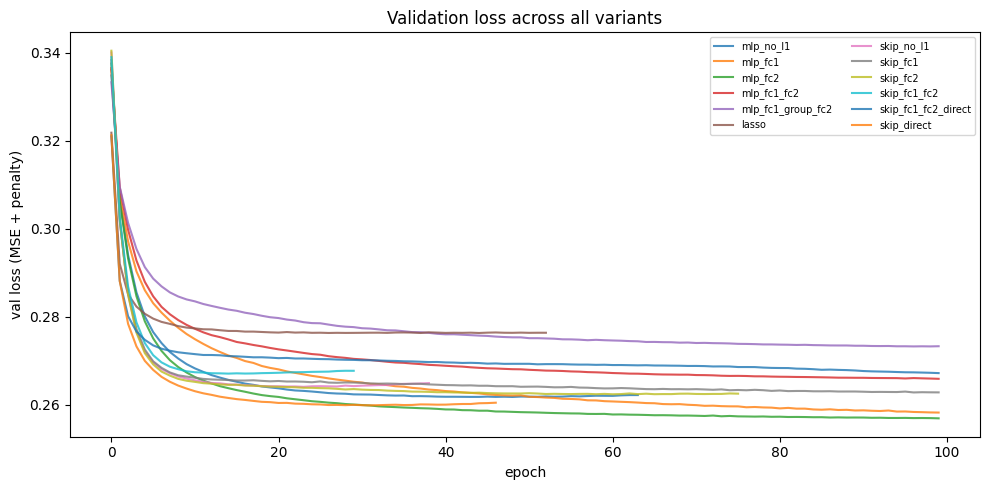

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, history in trained_histories.items():
    ax.plot(history['val_loss'], label=name, alpha=0.8)
ax.set_xlabel('epoch')
ax.set_ylabel('val loss (MSE + penalty)')
ax.set_title('Validation loss across all variants')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'nb11_val_loss_all_variants.png', dpi=150)
plt.show()

## Comparison table -- accuracy vs. interpretability
Train/test Pearson r, cognate rank-1 count, and median effective genes per
protein, side by side for every trained variant.

In [11]:
comparison_rows = []
per_variant_metrics = {}
per_variant_ranks = {}

for name, model in trained_models.items():
    metrics = train_test_metrics(
        model, X_rna_corr[train_idx], Y_protein_corr[train_idx],
        X_rna_corr[test_idx], Y_protein_corr[test_idx], matched_adt_names,
    )
    per_variant_metrics[name] = metrics

    importance_df = compute_importance(model, gene_union, matched_adt_names)
    cognate_ranks = cognate_gene_rank(importance_df, gene_map)
    per_variant_ranks[name] = cognate_ranks

    eff_genes = effective_genes_per_protein(model, matched_adt_names, gene_union)

    comparison_rows.append({
        'variant': name,
        'median_train_r': metrics['pearson_r_train'].median(),
        'median_test_r': metrics['pearson_r_test'].median(),
        'r_gap': metrics['r_gap'].median(),
        'cognate_rank1_count': int((cognate_ranks['cognate_rank'] == 1).sum()),
        'cognate_rank1_total': len(cognate_ranks),
        'median_effective_genes': eff_genes.median(),
    })

comparison_table = pd.DataFrame(comparison_rows).sort_values('median_train_r', ascending=False).reset_index(drop=True)
comparison_table

,variant,median_train_r,median_test_r,r_gap,cognate_rank1_count,cognate_rank1_total,median_effective_genes
0,skip_no_l1,0.491100,0.410090,0.082328,18,163,1863.0
1,skip_fc1,0.477232,0.416195,0.068075,12,163,1851.0
2,skip_fc2,0.476348,0.406918,0.073482,17,163,1851.0
3,skip_direct,0.469810,0.416955,0.045649,14,163,9.0
4,mlp_no_l1,0.463440,0.413458,0.045118,7,163,2092.0
5,skip_fc1_fc2,0.451417,0.402954,0.054753,32,163,1838.0
6,mlp_fc2,0.450720,0.426563,0.024204,13,163,2091.0
7,mlp_fc1,0.435642,0.427633,0.011628,8,163,1079.0
8,mlp_fc1_fc2,0.399280,0.396420,0.003881,11,163,662.0
9,skip_fc1_fc2_direct,0.398039,0.392910,0.005130,29,163,48.0


## Save results

In [12]:
comparison_table.to_csv(RESULTS_DIR / 'nb11_variant_comparison.csv', index=False)

for name in trained_models:
    per_variant_metrics[name].to_csv(RESULTS_DIR / f'nb11_{name}_per_protein_metrics.csv', index=False)
    per_variant_ranks[name].to_csv(RESULTS_DIR / f'nb11_{name}_cognate_ranks.csv', index=False)

print(f'Saved to {RESULTS_DIR}')
print('  nb11_variant_comparison.csv            -- all variants, accuracy + interpretability side by side')
print('  nb11_<variant>_per_protein_metrics.csv -- per variant, train/test Pearson r + R2')
print('  nb11_<variant>_cognate_ranks.csv       -- per variant, cognate RNA rank per protein')
print(f'  checkpoints/<variant>.pt               -- best-validation model weights, {len(trained_models)} variants')

Saved to /content/drive/MyDrive/covid_citeseq_project/results/mlp_variant_comparison
  nb11_variant_comparison.csv            -- all variants, accuracy + interpretability side by side
  nb11_<variant>_per_protein_metrics.csv -- per variant, train/test Pearson r + R2
  nb11_<variant>_cognate_ranks.csv       -- per variant, cognate RNA rank per protein
  checkpoints/<variant>.pt               -- best-validation model weights, 12 variants


## Top-variant re-run: full gene set (no HVG restriction)
`gene_union` above restricts RNA input to the 163 matched cognate genes plus
the top 2000 HVGs. Here we check whether that restriction is costing anything:
take the single best-performing variant from each of the 3 architecture
families (lasso, mlp, skip) by `median_test_r`, and retrain each one using
**every gene** in `covid_gex` as RNA input instead of `gene_union`.

Same normalization pipeline (log1p CP10k, library-size regression), same
train/val/test split -- only the RNA input width changes. This substantially
increases `rna_dim` (full transcriptome vs. ~2000 genes), so expect this
section to run noticeably slower than the main sweep above.

In [ ]:
def variant_family(name: str) -> str:
    """Map a variant name to its architecture family: lasso, mlp, or skip."""
    if name == 'lasso':
        return 'lasso'
    if name.startswith('mlp'):
        return 'mlp'
    if name.startswith('skip'):
        return 'skip'
    raise ValueError(f'Unrecognized variant family for {name!r}')


comparison_table['family'] = comparison_table['variant'].map(variant_family)
top_per_family = (
    comparison_table.sort_values('median_test_r', ascending=False)
    .groupby('family')
    .first()
    .reset_index()
)
print('Top variant per family (by median_test_r):')
top_per_family[['family', 'variant', 'median_test_r', 'cognate_rank1_count']]

Top variant per family (by median_train_r):


,family,variant,median_train_r,cognate_rank1_count
0,lasso,lasso,0.383659,38
1,mlp,mlp_no_l1,0.463440,7
2,skip,skip_no_l1,0.491100,18


### Build all-genes RNA input
Same `normalize_rna` / `regress_out_library_size` functions as above, applied to every gene instead of `gene_union`. Protein side (`Y_protein_corr`) is unchanged.

In [15]:
ALL_GENES = covid_gex.var_names.tolist()

rna_all_adata = normalize_rna(covid_gex, ALL_GENES)
X_rna_all = np.asarray(rna_all_adata.X.todense()) if hasattr(rna_all_adata.X, 'todense') else np.asarray(rna_all_adata.X)
X_rna_all = X_rna_all.astype(np.float32)

rna_all_raw_for_size = rna_all_adata.layers['raw']
rna_all_raw_for_size = np.asarray(rna_all_raw_for_size.todense()) if hasattr(rna_all_raw_for_size, 'todense') else np.asarray(rna_all_raw_for_size)

X_rna_all_corr = regress_out_library_size(X_rna_all, rna_all_raw_for_size)

print(f'X_rna_all_corr: {X_rna_all_corr.shape} (all genes)')
print(f'X_rna_corr:     {X_rna_corr.shape} (matched + HVG union, for comparison)')

: 

: 

: 

In [ ]:
train_loader_all = make_loader(X_rna_all_corr, Y_protein_corr, train_idx, BATCH_SIZE, shuffle=True)
val_loader_all   = make_loader(X_rna_all_corr, Y_protein_corr, val_idx,   BATCH_SIZE, shuffle=False)

### Train the 3 top variants on all genes

In [ ]:
trained_models_all_genes = {}
trained_histories_all_genes = {}

for _, row in top_per_family.iterrows():
    name = row['variant']
    print(f'\n=== Training {name} (all genes) ===')
    model, penalty_fn = build_variant(
        name,
        rna_dim=X_rna_all_corr.shape[1],
        protein_dim=Y_protein_corr.shape[1],
        hidden_dim=HIDDEN_DIM,
    )
    model, history = fit_model(
        model=model,
        train_loader=train_loader_all,
        val_loader=val_loader_all,
        penalty_fn=penalty_fn,
        num_epochs=NUM_EPOCHS,
        patience=PATIENCE,
        train_device=DEVICE,
        checkpoint_path=MODELS_DIR / f'{name}_all_genes.pt',
    )
    trained_models_all_genes[name] = model
    trained_histories_all_genes[name] = history

### All-genes comparison table
Same metrics as the main sweep, but `compute_importance` / `cognate_gene_rank` now rank each protein's cognate gene against the **full transcriptome**, not just the 2000-gene union -- a stricter test of rank-1.

In [ ]:
comparison_rows_all_genes = []
per_variant_metrics_all_genes = {}
per_variant_ranks_all_genes = {}

for name, model in trained_models_all_genes.items():
    metrics = train_test_metrics(
        model, X_rna_all_corr[train_idx], Y_protein_corr[train_idx],
        X_rna_all_corr[test_idx], Y_protein_corr[test_idx], matched_adt_names,
    )
    per_variant_metrics_all_genes[name] = metrics

    importance_df = compute_importance(model, ALL_GENES, matched_adt_names)
    cognate_ranks = cognate_gene_rank(importance_df, gene_map)
    per_variant_ranks_all_genes[name] = cognate_ranks

    eff_genes = effective_genes_per_protein(model, matched_adt_names, ALL_GENES)

    comparison_rows_all_genes.append({
        'variant': name,
        'gene_set': 'all_genes',
        'n_input_genes': len(ALL_GENES),
        'median_train_r': metrics['pearson_r_train'].median(),
        'median_test_r': metrics['pearson_r_test'].median(),
        'r_gap': metrics['r_gap'].median(),
        'cognate_rank1_count': int((cognate_ranks['cognate_rank'] == 1).sum()),
        'cognate_rank1_total': len(cognate_ranks),
        'median_effective_genes': eff_genes.median(),
    })

comparison_table_all_genes = pd.DataFrame(comparison_rows_all_genes)
comparison_table_all_genes

### Side-by-side: matched+HVG union vs. all genes
For each of the 3 selected variants, does the full gene set help, hurt, or make no difference?

In [ ]:
gene_union_top = top_per_family[[
    'variant', 'median_train_r', 'median_test_r', 'r_gap',
    'cognate_rank1_count', 'cognate_rank1_total', 'median_effective_genes',
]].copy()
gene_union_top['gene_set'] = 'matched_hvg_union'
gene_union_top['n_input_genes'] = len(gene_union)

gene_set_comparison = pd.concat([gene_union_top, comparison_table_all_genes], ignore_index=True)
gene_set_comparison = gene_set_comparison.sort_values(['variant', 'gene_set']).reset_index(drop=True)
gene_set_comparison

### Save all-genes results

In [ ]:
comparison_table_all_genes.to_csv(RESULTS_DIR / 'nb11_variant_comparison_all_genes.csv', index=False)
gene_set_comparison.to_csv(RESULTS_DIR / 'nb11_gene_set_comparison_top_variants.csv', index=False)

for name in trained_models_all_genes:
    per_variant_metrics_all_genes[name].to_csv(RESULTS_DIR / f'nb11_{name}_all_genes_per_protein_metrics.csv', index=False)
    per_variant_ranks_all_genes[name].to_csv(RESULTS_DIR / f'nb11_{name}_all_genes_cognate_ranks.csv', index=False)

print(f'Saved to {RESULTS_DIR}')
print('  nb11_variant_comparison_all_genes.csv       -- top-3 variants, retrained on all genes')
print('  nb11_gene_set_comparison_top_variants.csv   -- matched+HVG union vs. all genes, side by side')
print('  nb11_<variant>_all_genes_per_protein_metrics.csv / _cognate_ranks.csv -- per top variant')

## Summary
Fill in after running:
- Best accuracy variant (median_test_r):
- Best interpretability variant (cognate_rank1_count):
- Variants worth carrying forward to the NeurIPS (GSE194122) pipeline:
- Any variant that failed to converge / degenerate loss:
- Does the full gene set beat the matched+HVG union for any of the 3 top variants?
- Which gene set to standardize on for the NeurIPS pipeline: